# What are characteristics of countries that do well in the Olympics?

https://github.com/annacgraves/usable_ai_final_project/tree/main

## Introduction

With the Winter Olympics being the most recent world event, I thought it would be appropriate to take a look at the results of previous Olympics. I have always had fun watching the Olympics, but recently it has piqued my interest more because the athletes are closer to my age, so it becomes more relatable entertainment (I was a college athlete). I also think it is neat that an event like this can bring the world together.

Specifically for this project, I wanted to do a deeper dive into why some countries might be more successful than others. My initial thought was countries with larger populations would dominate (like China). However, this year Norway dominated the charts. I kept thinking of reasons why this might be the case. Having a project with more solid numeric evidence would be interesting to me.

My goal is to gather total Olympic medal counts by each country, and determine through analysis if there is a pattern among top performing countries. To do this, I aim to use country details such as climate, economic, and population data.

## Data collection

These are the links of databases I used throughout this project:
- https://www.kaggle.com/datasets/rse1982/olympic-medalists - medal_counts
- https://www.kaggle.com/datasets/prasad22/global-economy-indicators - economy
- https://www.kaggle.com/datasets/chandanchoudhury/world-population-dataset?select=world_population_by_country_2023.csv - population
- https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository - weather

## Data Exploration and Statistical Analysis

For the Exploration, I decided to focus on the Olympic Medalists data.

The raw data of Olympic Medalists does not seem like a lot, but we can take away more than we could expect. The only fields we are working with in this initial dataset are season, year, medal (like gold, silver, or bronze), country code, country, games, sport, event gender, and event name.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

df_medals = pd.read_csv('olympic_medals.csv')

display(df_medals)

,season,year,medal,country_code,country,games,sport,event_gender,event_name
0,Summer,1896,Gold,USA,United States,1896 Athens,Athletics,Men's,100m
1,Summer,1896,Silver,GER,Germany,1896 Athens,Athletics,Men's,100m
2,Summer,1896,Bronze,HUN,Hungary,1896 Athens,Athletics,Men's,100m
3,Summer,1896,Bronze,USA,United States,1896 Athens,Athletics,Men's,100m
4,Summer,1896,Gold,USA,United States,1896 Athens,Athletics,Men's,400m
...,...,...,...,...,...,...,...,...,...
21256,Summer,2020,Silver,NGR,Nigeria,2020 Tokyo,Wrestling,Mixed,68 kg
21257,Summer,2020,Bronze,UKR,Ukraine,2020 Tokyo,Wrestling,Mixed,68 kg
21258,Summer,2020,Gold,GER,Germany,2020 Tokyo,Wrestling,Mixed,76 kg
21259,Summer,2020,Silver,USA,United States,2020 Tokyo,Wrestling,Mixed,76 kg


In [4]:
df_medals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21261 entries, 0 to 21260
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   season        21261 non-null  object
 1   year          21261 non-null  int64 
 2   medal         21261 non-null  object
 3   country_code  21261 non-null  object
 4   country       21261 non-null  object
 5   games         21261 non-null  object
 6   sport         21261 non-null  object
 7   event_gender  21261 non-null  object
 8   event_name    21261 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.5+ MB


In [5]:
int(df_medals["year"].min()),int(df_medals["year"].max())

(1896, 2024)

In [6]:
df_medals["country"].unique()

array(['United States', 'Germany', 'Hungary', 'Great Britain',
       'Australia', 'Greece', 'France', 'Austria', 'Denmark',
       'Switzerland', 'Mixed Team', 'Belgium', 'India', 'Luxembourg',
       'Sweden', 'Canada', 'Norway', 'Bohemia', 'Italy', 'Cuba',
       'Netherlands', 'Spain', 'South Africa', 'Australasia', 'Finland',
       'Russian Empire', 'Estonia', 'New Zealand', 'Brazil', 'Japan',
       'Czechoslovakia', 'Argentina', 'Poland', 'Portugal', 'Uruguay',
       'Yugoslavia', 'Romania', 'Haiti', 'Chile', 'Ireland', 'Egypt',
       'Philippines', 'Latvia', 'Mexico', 'Turkey', 'Panama',
       'Jamaica, British', 'Ceylon', 'Korea Republic', 'Puerto Rico',
       'Peru', 'Trinidad and Tobago, British', 'Iran', 'USSR',
       'Venezuela', 'Bulgaria', 'Lebanon', 'Unified Team of Germany',
       'Iceland', 'Pakistan', 'Bahamas', 'British West Indies',
       'Ethiopia', 'Morocco', 'Republic of China (Taiwan)',
       'United Arab Republic (Egypt, Syria)', 'Ghana',
       'Sing

In [7]:
df_medals["games"].unique()

array(['1896 Athens', '1900 Paris', '1904 St Louis', '1908 London',
       '1912 Stockholm', '1920 Antwerp', '1924 Paris', '1928 Amsterdam',
       '1932 Los Angeles', '1936 Berlin', '1948 London', '1952 Helsinki',
       '1956 Melbourne / Stockholm', '1960 Rome', '1964 Tokyo',
       '1968 Mexico', '1972 Munich', '1976 Montreal', '1980 Moscow',
       '1984 Los Angeles', '1988 Seoul', '1992 Barcelona', '1996 Atlanta',
       '2000 Sydney', '2004 Athens', '2008 Beijing', '2012 London',
       '2016 Rio de Janeiro', '2024 Paris', '1924 Chamonix',
       '1928 St. Moritz', '1932 Lake Placid',
       '1936 Garmisch-Partenkirchen', '1948 St. Moritz', '1952 Oslo',
       "1956 Cortina d'Ampezzo", '1960 Squaw Valley', '1964 Innsbruck',
       '1968 Grenoble', '1972 Sapporo', '1976 Innsbruck',
       '1980 Lake Placid', '1984 Sarajevo', '1988 Calgary',
       '1992 Albertville', '1994 Lillehammer', '1998 Nagano',
       '2002 Salt Lake City', '2006 Turin', '2010 Vancouver',
       '2014 Sochi

I was able to gather some basic information that would be important to the beginnings of this project. To start, we are working with 174. In other words, there are 174 countries that have earned at least one medal of any kind in any of the Olympics between 1896 and 2024. This is a lot, so I decided to limit my scope to the top 10 countries. This decision can also be seen through some visualizations.

### Histograms

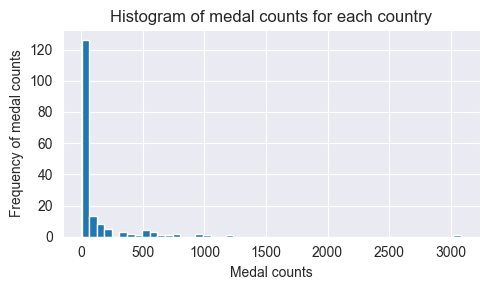

In [8]:
fig = plt.figure(figsize=(5, 3))
plt.hist(df_medals['country'].value_counts(),bins=50)
plt.xlabel('Medal counts')
plt.ylabel('Frequency of medal counts')
plt.title("Histogram of medal counts for each country")
plt.tight_layout()
plt.show()

This shows the histogram of country medal counts. As expected, there is a large number of countries that have earned only a few medals in the history of the Olympic games. While this data is not surprising, it does drown out the data of the high performers.

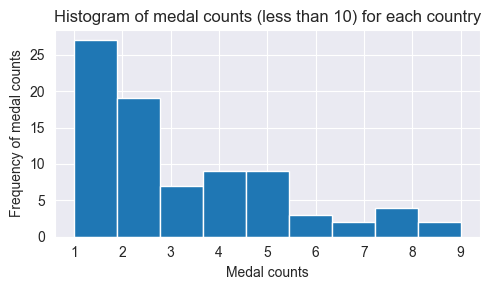

In [9]:
fig_1 = plt.figure(figsize=(5, 3))
counts = df_medals['country'].value_counts()
more_than_1 = counts[counts < 10]
plt.hist(more_than_1,bins=9)
plt.xlabel('Medal counts')
plt.ylabel('Frequency of medal counts')
plt.title("Histogram of medal counts (less than 10) for each country")
plt.tight_layout()
plt.show()

This allows us to look into a subset of the data - countries that have earned a total of less than 10 medals. When clustering, I may be able to include some of these countries to see if there are differences between top performers and lower performers.

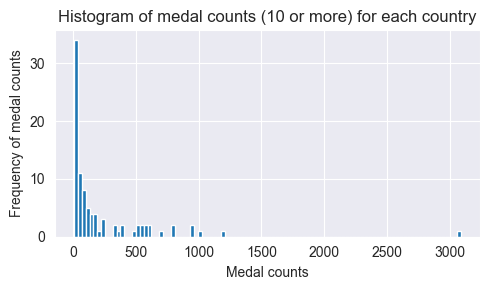

In [10]:
fig_2 = plt.figure(figsize=(5, 3))
counts = df_medals['country'].value_counts()
more_than_1 = counts[counts >= 10]
plt.hist(more_than_1,bins=100)
plt.xlabel('Medal counts')
plt.ylabel('Frequency of medal counts')
plt.title("Histogram of medal counts (10 or more) for each country")
plt.tight_layout()
plt.show()

In this last histogram we can see the number of countries that bring in high counts of medals. The shape of the graph is consistent as we would expect with this cumulative data, but what is interesting to note is the one extreme outlier (which an outsider familiar with the Olympics might assume is the USA).

While all of these visualizations are helpful in understanding the medal count data, it does not tell us much about the countries.

### Data Cleaning

In [11]:
df_medals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21261 entries, 0 to 21260
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   season        21261 non-null  object
 1   year          21261 non-null  int64 
 2   medal         21261 non-null  object
 3   country_code  21261 non-null  object
 4   country       21261 non-null  object
 5   games         21261 non-null  object
 6   sport         21261 non-null  object
 7   event_gender  21261 non-null  object
 8   event_name    21261 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.5+ MB


In [12]:
df_medals.drop_duplicates(inplace=True)

### Data Visualization

For the sake of learning more about the data, I decided to focus on a subset of countries (starting with a focus on the USA).

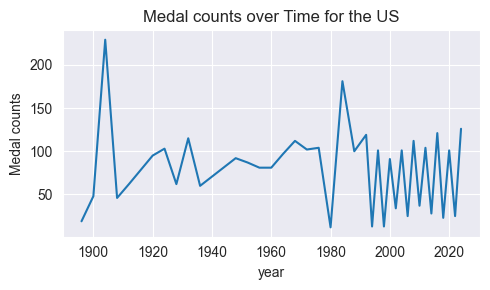

In [13]:
plt.figure(figsize=(5, 3))
df_usa = df_medals[df_medals['country'] == 'United States']
df_usa.groupby("year").size().plot()
plt.ylabel('Medal counts')
plt.title('Medal counts over Time for the US')
plt.tight_layout()
plt.show()

This shows us the total medal counts for the US each year. The first thing I notice when I see this graph is how there are typical random ups and downs from the beginning until around 1990. After 1990, the data rises and falls pretty consistently. I took a closer look at the games the dataset records, and it does not contain any Winter Olympics information until 1994. This aligns with the trend we are seeing, and also explains the peaks and valleys - Summer Olympics offers more events than the Winter Olympics. Knowing this about my data will help direct me when I want to begin clustering countries. I can have two datasets - one before 1990 and one after 1990.

<Figure size 500x300 with 0 Axes>

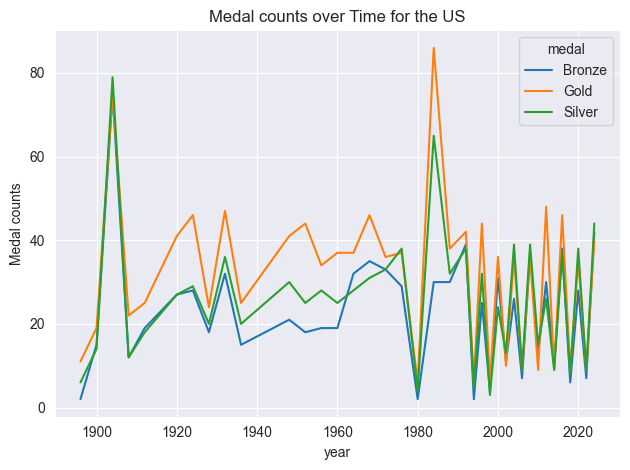

In [14]:
plt.figure(figsize=(5, 3))
df_usa = df_medals[df_medals['country'] == 'United States']
df_usa.groupby(["year", 'medal']).size().unstack().plot()
plt.ylabel('Medal counts')
plt.title('Medal counts over Time for the US')
plt.tight_layout()
plt.show()

This was an interesting visualization that shows how each medal type count moves iin sync with the others.

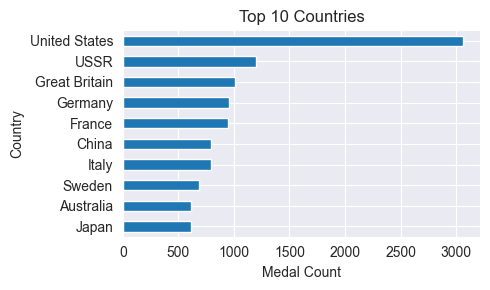

In [16]:
plt.figure(figsize=(5, 3))
df_medal_counts = df_medals.groupby("country").size()
top_10 = df_medal_counts.nlargest(10)
ax = top_10.plot(kind="barh")
plt.xlabel('Medal Count')
plt.ylabel('Country')
plt.title('Top 10 Countries')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

To expand the scope outside of just the US, I gathered the top 10 countries in medal counts. Again, we can see here that the US is a huge outlier, but compared to the rest of the countries in the dataset, these 10 are clearly our top performers. Using this, I was able to generate the next visualization.

<Figure size 500x300 with 0 Axes>

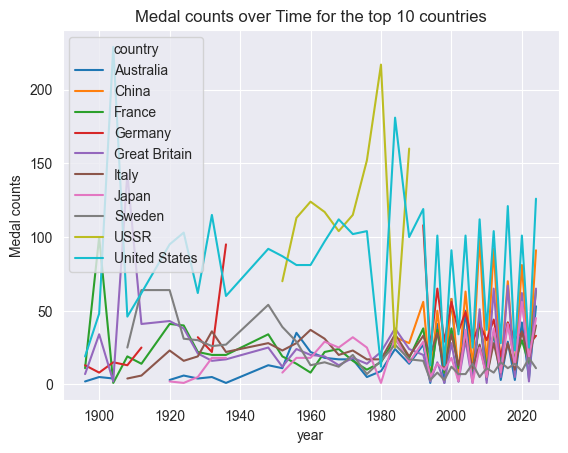

In [17]:
plt.figure(figsize=(5, 3))
top_10_years = df_medals[df_medals['country'].isin(top_10.index)]
top_10_years.groupby(["year", 'country']).size().unstack().plot()
plt.ylabel('Medal counts')
plt.title('Medal counts over Time for the top 10 countries')
plt.show()

In this last figure the general pattern remains with the top 10 countries. From 1994 and after, there is a pattern of peaks and valleys, again indicating the presence of Winter Olympics data. There are other features that stand out that are interesting, but not pertinent to my project, such as how history impacts this graph. For example, when the Olympics were hosted by Moscow in 1984, the US participated in/led a boycott during the Soviet-Afghan war and many other countries followed suit. This explains the massive spike for the USSR (yellow) and the zero count for the US (blue).

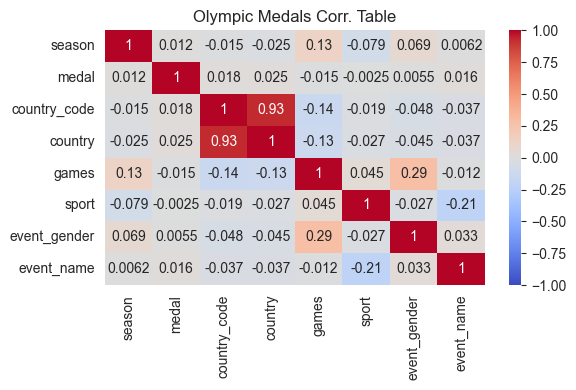

In [18]:
df_medals_numbers = pd.DataFrame()

for col in df_medals.select_dtypes(include=['object', 'category']).columns:
    df_medals_numbers[col] = df_medals[col].astype('category').cat.codes

df_medals_numbers = (df_medals_numbers - df_medals_numbers.min()) / (df_medals_numbers.max() - df_medals_numbers.min())

correlation_table = df_medals_numbers.corr(method='spearman')

# Create heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_table, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Olympic Medals Corr. Table')
plt.tight_layout()
plt.show()

In this correlation graph, we can see that almost none of the variables are highly correlated (except the obvious country vs country code).

### Get Other Country Information

This is where I begin to bring in other information that will help us learn about the countries. I am using the data files mentioned earlier and I begin to create the primary DataFrame that will be used for analysis. I also want to note that while I did thorough data exploration on a select handful of countries, the actual machine learning implementation will be applied to the whole medal count dataset.

In [21]:
import sqlite3
import pandas as pd

dbpath = 'finalDB.sqlite'
conn = sqlite3.connect(dbpath)

# Read CSV files
glob_econ_ind_df = pd.read_csv('Global Economy Indicators.csv')
glob_weather_df = pd.read_csv('GlobalWeatherRepository.csv')
country_stats_df = pd.read_csv('world_country_stats.csv')
population_df = pd.read_csv('world_population_by_country_2023.csv')

# Insert into SQLite tables
df_medals.to_sql('olympic_medals', conn, if_exists='replace', index=False)
glob_econ_ind_df.to_sql('economy', conn, if_exists='replace', index=False)
glob_weather_df.to_sql('weather', conn, if_exists='replace', index=False)
country_stats_df.to_sql('stats', conn, if_exists='replace', index=False)
population_df.to_sql('population', conn, if_exists='replace', index=False)

234

This seems like a massive SQL statement, but it really is to clean up the data. For shorter term projects like this I would rather clean it this way than alter the data because mistakes can be undone. The primary way I am cleaning the data is consolidating political/Olympic representative countries to match with the physical countries (take for example Russia), remove Olympic representative teams that are groups of countries (Refugee Olympic Team), and remove countries that no longer exist. This is simply because I cannot get external data on these countries, like weather or population. Another way I clean the data is to get the average, minimum, and maximum temperatures, as well as get the most current information. The weather and economic databases collect data on a country over a range of days, so I had to consolidate that information.

In [22]:
sql_statement = '''
        WITH counts AS (
            SELECT
                COUNT(*) AS medal_count,
                CASE
                    WHEN country in ('AIN', 'USSR', 'Russian Federation', 'Russian Empire', 'ROC', 'Olympic Athletes from Russia') THEN 'Russia'
                    WHEN country = 'Great Britain' THEN 'United Kingdom'
                    WHEN country in ('German Democratic Republic', 'Unified Team of Germany', 'Federal Republic of Germany') THEN 'Germany'
                    WHEN country = 'Korea Republic' THEN 'South Korea'
                    WHEN country = 'Korea DPR' THEN 'North Korea'
                    WHEN country = 'Bohemia' THEN 'Czech Republic'
                    WHEN country = 'Singapore, British' THEN 'Singapore'
                    WHEN country in ('Hong Kong, China', 'Hong Kong, British') THEN 'Hong Kong'
                    WHEN country = 'Chinese Taipei' THEN 'Taiwan'
                    WHEN country = 'Republic of China (Taiwan)' THEN 'Taiwan'
                    WHEN country = 'Jamaica, British' THEN 'Jamaica'
                    WHEN country in ('Trinidad and Tobago, British', 'Trinidad and Tobago') THEN 'Trinidad and Tobago'
                    WHEN country = 'Cape Verde' THEN 'Cabo Verde'
                    WHEN country = 'Ceylon' THEN 'Sri Lanka'
                    WHEN country = 'Ivory Coast' THEN 'Cote d''Ivoire'
                    WHEN country = 'Macedonia' THEN 'North Macedonia'
                    WHEN country = 'Netherlands Antilles' THEN 'Netherlands'
                    ELSE country
                END AS country_main
            FROM olympic_medals
            WHERE country_main not in
                                ('Yugoslavia', 'Czechoslovakia', 'Yugoslavia Federal Republic',
                                 'Serbia and Montenegro', 'Virgin Islands, US', 'Australasia', 'Mixed Team',
                                 'United Arab Republic (Egypt, Syria)', 'British West Indies',
                                 'Independent Olympic Athletes', 'Refugee Olympic Team', 'Independent Participants (ex Yugoslavia)',
                                 'Unified Team (ex USSR)', 'Bermuda', 'Cabo Verde', 'Kosovo', 'Taiwan', 'Kyrgyzstan', 'Moldova', 'Cote d''Ivoire',
                                'Czech Republic', 'North Macedonia', 'Puerto Rico')
            GROUP BY
                CASE
                    WHEN country in ('AIN', 'USSR', 'Russian Federation', 'Russian Empire', 'ROC', 'Olympic Athletes from Russia') THEN 'Russia'
                    WHEN country = 'Great Britain' THEN 'United Kingdom'
                    WHEN country in ('German Democratic Republic', 'Unified Team of Germany', 'Federal Republic of Germany') THEN 'Germany'
                    WHEN country = 'Korea Republic' THEN 'South Korea'
                    WHEN country = 'Korea DPR' THEN 'North Korea'
                    WHEN country = 'Bohemia' THEN 'Czech Republic'
                    WHEN country = 'Singapore, British' THEN 'Singapore'
                    WHEN country in ('Hong Kong, China', 'Hong Kong, British') THEN 'Hong Kong'
                    WHEN country = 'Chinese Taipei' THEN 'Taiwan'
                    WHEN country = 'Republic of China (Taiwan)' THEN 'Taiwan'
                    WHEN country = 'Jamaica, British' THEN 'Jamaica'
                    WHEN country in ('Trinidad and Tobago, British', 'Trinidad and Tobago') THEN 'Trinidad and Tobago'
                    WHEN country = 'Cape Verde' THEN 'Cabo Verde'
                    WHEN country = 'Ceylon' THEN 'Sri Lanka'
                    WHEN country = 'Ivory Coast' THEN 'Cote d''Ivoire'
                    WHEN country = 'Macedonia' THEN 'North Macedonia'
                    WHEN country = 'Netherlands Antilles' THEN 'Netherlands'
                    ELSE country
                END
        )

        , economy_latest AS (
            SELECT *, CASE
                    WHEN TRIM(" Country ") = 'Russian Federation' THEN 'Russia'
                    WHEN TRIM(" Country ") = 'D.P.R. of Korea' THEN 'North Korea'
                    WHEN TRIM(" Country ") = 'Republic of Korea' THEN 'South Korea'
                    WHEN TRIM(" Country ") = 'Türkiye' THEN 'Turkey'
                    WHEN TRIM(" Country ") = 'Iran (Islamic Republic of)' THEN 'Iran'
                    WHEN TRIM(" Country ") = 'Venezuela (Bolivarian Republic of)' THEN 'Venezuela'
                    WHEN TRIM(" Country ") = 'Viet Nam' THEN 'Vietnam'
                    WHEN TRIM(" Country ") = 'Czechia' THEN 'Czech Republic'
                    WHEN TRIM(" Country ") = 'Taiwan (Republic of China)' THEN 'Taiwan'
                    WHEN TRIM(" Country ") = 'China, Hong Kong SAR' THEN 'Hong Kong'
                    WHEN TRIM(" Country ") = 'Republic of Moldova' THEN 'Moldova'
                    WHEN TRIM(" Country ") = 'Syrian Arab Republic' THEN 'Syria'
                    WHEN TRIM(" Country ") = 'Côte d''Ivoire' THEN 'Cote d''Ivoire'
                    WHEN TRIM(" Country ") = 'U.R. of Tanzania: Mainland' THEN 'Tanzania'
                    ELSE TRIM(" Country ")
                END AS country_main
            FROM (SELECT *,
                       ROW_NUMBER() OVER (PARTITION BY " Country " ORDER BY " Year " DESC) AS rn
                  FROM economy)
            WHERE rn = 1
        )

        , avg_weather AS (
            SELECT
                CASE
                    WHEN country = 'United States of America' THEN 'United States'
                    ELSE country
                END AS country_main,
                AVG(temperature_celsius) AS avg_temp_c,
                MIN(temperature_celsius) AS min_temp_c,
                MAX(temperature_celsius) AS max_temp_c,
                AVG(humidity) AS avg_humidity,
                AVG(wind_kph) AS avg_wind_kph,
                AVG(pressure_mb) AS avg_pressure_mb,
                AVG(precip_mm) AS avg_precip_mm,
                AVG(uv_index) AS avg_uv
            FROM weather
            GROUP BY country
        )

        SELECT a.*, b." Total Value Added ", c.*, d.*, e.*
        FROM counts a
        LEFT JOIN economy_latest b ON a.country_main = TRIM(b.country_main)
        LEFT JOIN avg_weather c ON a.country_main = c.country_main
        LEFT JOIN stats d ON a.country_main = d.country
        LEFT JOIN population e ON a.country_main = e.country
        ORDER BY a.country_main;
    '''

country_stats = pd.read_sql_query(sql_statement, conn)

conn.close()


## Machine learning implementation

I start by doing a little more data cleaning - simply removing highly correlated features. Also, there are a lot of variables in this dataset, so I will only focus on the numeric variables.

In [25]:
def correlation_map_clean_df(df_):
    df_ = df_.loc[:, ~df_.columns.duplicated()]

    df_numeric = df_.select_dtypes(include=['number'])

    df_numeric = df_numeric.dropna(axis=1, how='all')
    df_numeric = df_numeric.fillna(df_numeric.median())
    df_numeric = df_numeric.drop(columns=['world_share', 'avg_humidity', 'fertility_rate'])

    corr_table = df_numeric.corr(method='spearman')

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_table, vmin=-1, vmax=1)
    plt.title('Numeric Feature Correlation')
    plt.tight_layout()
    plt.show()
    return df_.select_dtypes(include=['number']).join(df_['country_main'])

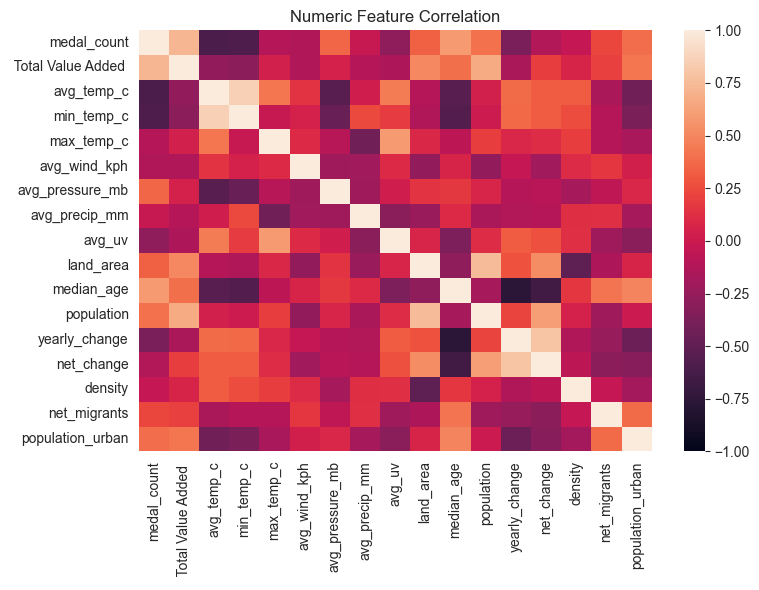

,medal_count,Total Value Added,avg_temp_c,min_temp_c,max_temp_c,avg_humidity,avg_wind_kph,avg_pressure_mb,avg_precip_mm,avg_uv,...,fertility_rate,median_age,population,yearly_change,net_change,density,net_migrants,population_urban,world_share,country_main
0,2,1.427850e+10,18.769318,-6.7,36.3,27.150568,8.453125,1011.579545,0.038196,5.713068,...,4.4,17.0,42239854,2.70,1111083,65,-65846,26.0,0.53,Afghanistan
1,2,1.592339e+10,19.317664,-4.7,39.2,57.311966,8.619088,1015.327635,0.144345,3.232764,...,1.4,38.0,2832439,-0.35,-9882,103,-8000,67.0,0.04,Albania
2,20,1.570000e+11,20.325963,1.4,38.2,64.042796,13.027532,1016.985735,0.051997,2.568616,...,2.8,28.0,45606480,1.57,703255,19,-9999,75.0,0.57,Algeria
3,80,4.050000e+11,15.080456,0.3,27.3,82.239658,10.420970,1015.763195,0.095264,0.905563,...,1.9,32.0,45773884,0.58,263566,17,3718,94.0,0.57,Argentina
4,22,1.258265e+10,16.684637,-13.0,39.3,44.886202,7.084211,1016.366999,0.043912,4.612660,...,1.6,35.0,2777970,-0.09,-2499,98,-5000,67.0,0.03,Armenia


In [26]:
country_df = correlation_map_clean_df(country_stats)
country_df.head()

The model I will use is the random forest classifier. I will then use this classifier to apply feature selection to see what features could best predict high performing countries. To make the data ready for this classifier, I grouped the countries into 1 of three categories: low, mid, and high performers.

In [27]:
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

def RFC(original):
    data = original.copy()

    data['medal_class'] = pd.qcut(
        data['medal_count'],
        q=3,
        labels=['1_low', '2_mid', '3_high']
    )

    x_features = data.drop(columns=['medal_class', 'country_main', 'medal_count']).columns.tolist()
    y_feature = 'medal_class'

    X = data[x_features]
    y = data[y_feature]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    scaler = preprocessing.StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    rf_classifier = RandomForestClassifier()
    rf_classifier.fit(X_train_scaled, y_train)

    param_grid_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'max_features': ['sqrt', 'log2'],
        'criterion': ['gini', 'entropy']
    }

    select = SelectFromModel(RandomForestClassifier(), threshold='median')
    select.fit(X_train_scaled, y_train)
    X_train_selected = select.transform(X_train_scaled)
    X_test_selected = select.transform(X_test_scaled)
    selected_features = X_train.columns[select.get_support()]
    print("Selected features after selection:")
    print(selected_features.tolist())

    grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5)
    grid_rf.fit(X_train_selected, y_train)

    y_pred_rf = grid_rf.predict(X_test_selected)

    print("Random Forest:")
    print(classification_report(y_true=y_test, y_pred=y_pred_rf))

    conf_matrix_dt = confusion_matrix(y_test, y_pred_rf) # COMPLETE

    plt.figure(figsize=(10, 10))
    sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', xticklabels=grid_rf.classes_, yticklabels=grid_rf.classes_)
    plt.title('Confusion Matrix - Random Forest Classifier')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    y_score = rf_classifier.predict_proba(X_test_scaled)
    chosenClass = "3_high"
    chosenClassIndex = rf_classifier.classes_.tolist().index(chosenClass)
    fpr, tpr, _ = roc_curve(y_test == chosenClass, y_score[:, chosenClassIndex])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for "{chosenClass}" (Random Forest)')

    plt.legend(loc='lower right')

    plt.show()
    return selected_features.tolist(), data

Selected features after selection:
[' Total Value Added ', 'avg_temp_c', 'min_temp_c', 'avg_pressure_mb', 'avg_uv', 'fertility_rate', 'median_age', 'population', 'net_migrants', 'population_urban']
Random Forest:
              precision    recall  f1-score   support

       1_low       0.85      0.69      0.76        16
       2_mid       0.46      0.55      0.50        11
      3_high       0.79      0.85      0.81        13

    accuracy                           0.70        40
   macro avg       0.70      0.69      0.69        40
weighted avg       0.72      0.70      0.71        40



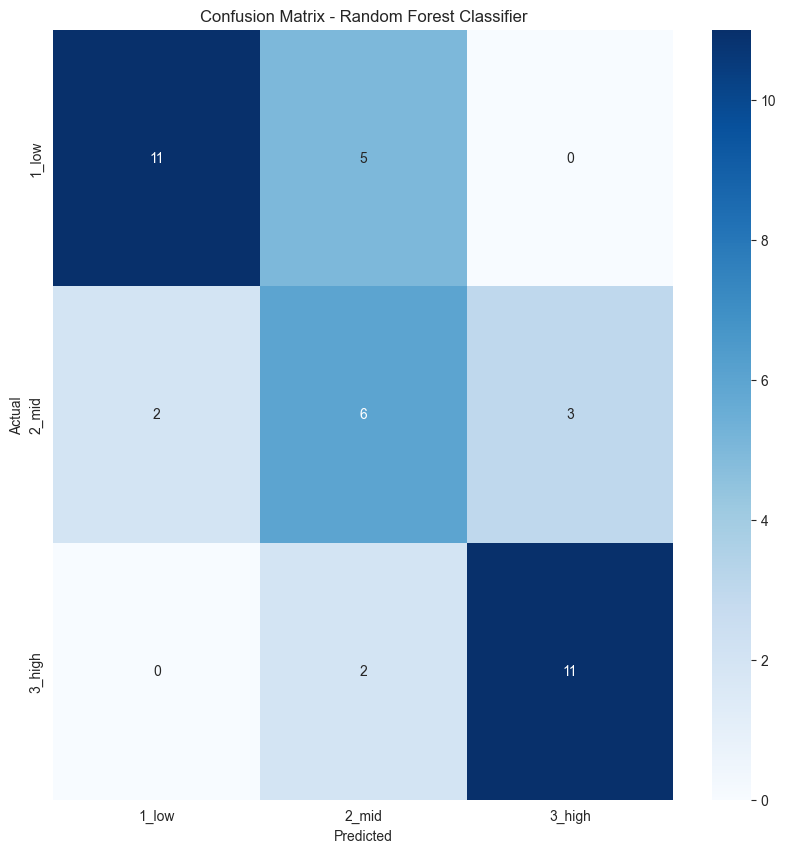

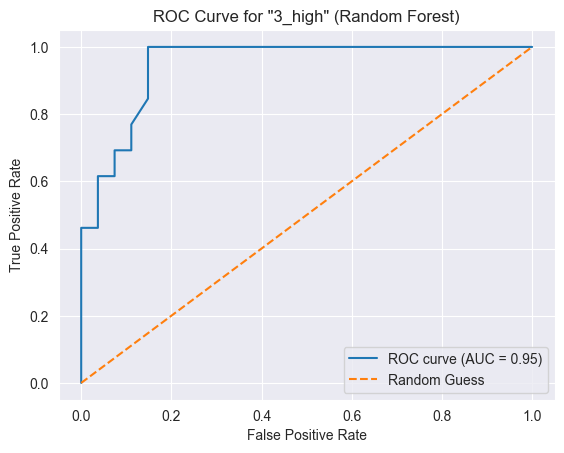

In [36]:
determining_features, grouped_df = RFC(country_df)

Above, we can see the results of this machine learning method, and the selected features. Honestly, the success varies a lot every time I run it. Accuracy tends to range from 50% to 80%. However, it does not do a terrible job clustering the data as seen with the AUC value. We can take a closer look at the selected features to see what we can learn about the high performing countries.

## Results and interpretation

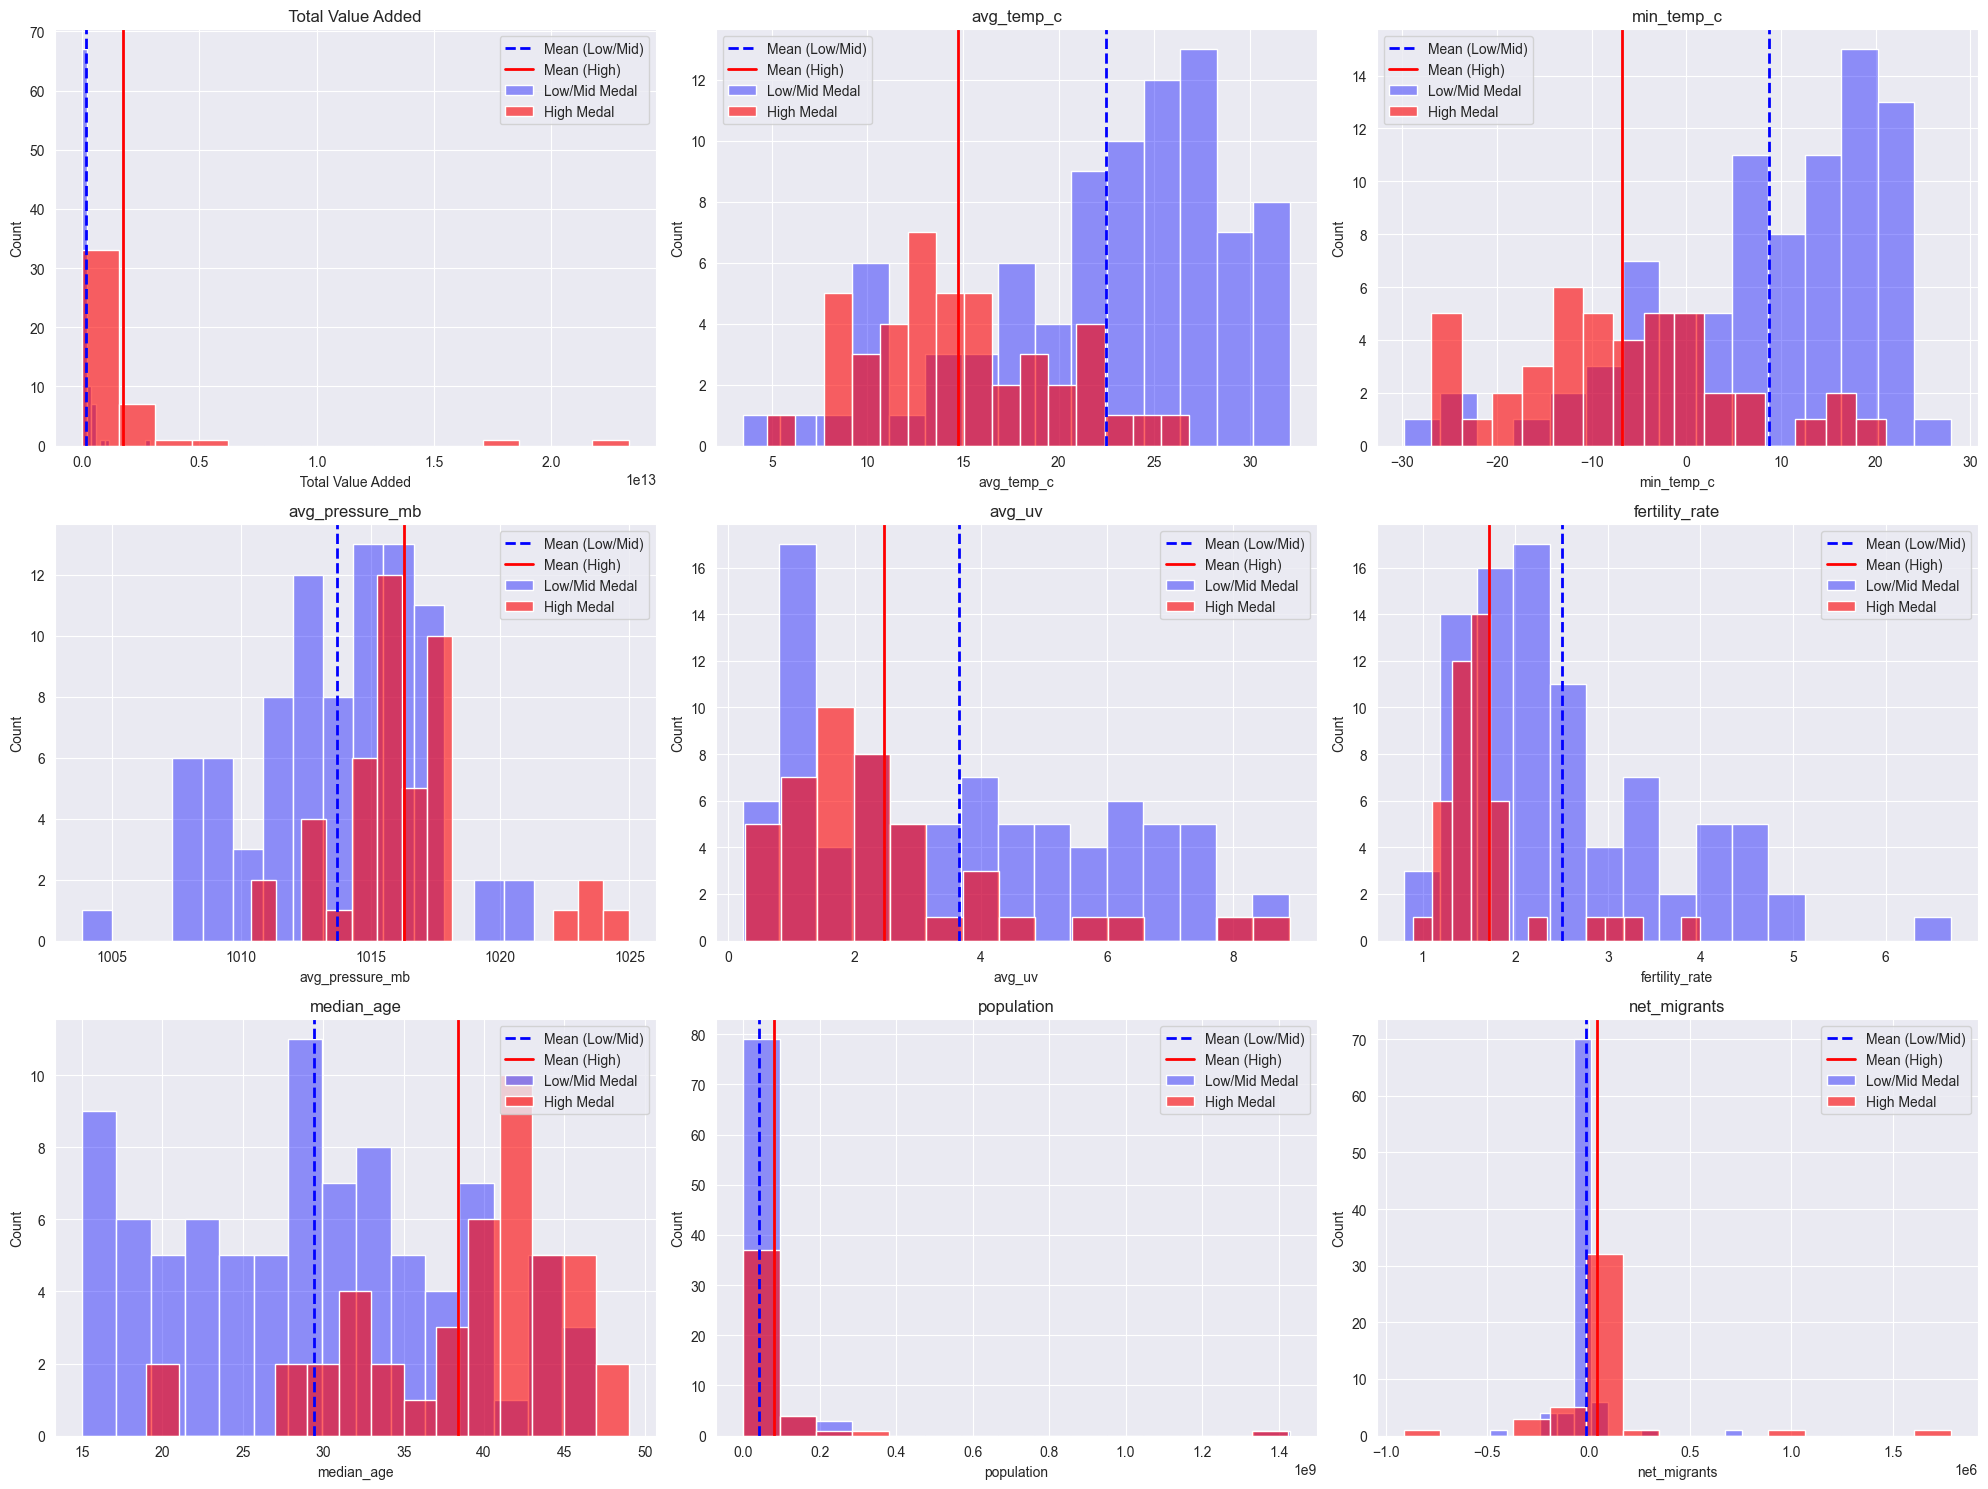

In [42]:
high_rows = grouped_df[grouped_df['medal_class'] == '3_high']
low_med_rows = grouped_df[grouped_df['medal_class'].isin(['2_mid', '1_low'])]

import matplotlib.pyplot as plt
import seaborn as sns

cols = determining_features

plt.figure(figsize=(20, 15))

for i, col in enumerate(cols[:9], 1):
    plt.subplot(3, 3, i)

    # distributions
    sns.histplot(low_med_rows[col], bins=15, color='blue', alpha=0.4, label='Low/Mid Medal')
    sns.histplot(high_rows[col], bins=15, color='red', alpha=0.6, label='High Medal')

    # means
    mean_all = low_med_rows[col].mean()
    mean_high = high_rows[col].mean()

    # plot mean lines
    plt.axvline(mean_all, color='blue', linestyle='--', linewidth=2, label='Mean (Low/Mid)')
    plt.axvline(mean_high, color='red', linestyle='-', linewidth=2, label='Mean (High)')

    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

The purple is the data of all the countries (with data) and the pink is the data of the high performers.

Starting with total value added, successful countries typically have a higher value, meaning the amount of money their economy produces (goods/services produced minus input cost) is higher. This is consistent with what we would think. Countries with more resources can invest more in training great athletes. Along the same lines, these same economically wealthy countries have lower fertility rates. Outside the Olympics, these two features are connected.

Successful countries also tend to have a lower average temperature, as well as a lower minimum temperature and lower average UV. My guess is the Winter Olympic data being included could contribute to this being the case. Also, more (as in the number of more) wealthy countries can be found on the northern half of the globe, aligning with the total value added conclusion.

On the other hand, air pressure tends to be higher for successful countries. My only assumption is that having that higher air pressure could provide more consistent weather, so there is more time to practice outside.

The median age is higher for successful countries, meaning more of the population tends to live longer. My thought is that the general population can afford to spend their prime younger years on training, and focus on making a living in their athletic retirement years. For the countries with a lower median age, they might not be able to spend their youth dedicated to training.

Population and net migrants are not as huge of a factor as I thought. The successful average is only a bit higher than the rest.





## Discussion and conclusions

I would say that this analysis confirmed what I thought for the most part. I figured countries that are wealthier/ have better global economic standings would tend to earn more medals in the Olympics. I would even say that the weather stats point to that being the case as well (cooler countries having a better economic standing compared to warmer countries). I was surprised by the population stats. Even though it does play a part in the classification, I thought there would be a much larger divide in population counts. I think a bias/ limitation is that there were way more countries with lower medal counts than countries with higher medal counts. This could have caused some bias with the classification model. If I could gather more country data, that might be able to help better the results. If I wanted to continue this research further, I might run the same method on subgroups of medal counts. For example, separate Summer and Winter, or look into the breakdown of events.

## Handling negative results

The largest problem I ran into was the accuracy of the classification model. It did the high class and low class very well, but it was pretty fuzzy on the mid class, resulting in a lower accuracy score. I believe this is because of the bias problem I mentioned before. I am aware that the data is cumulative, so that might also contribute to the gap of high medal counts and low medal counts. To relieve this problem, I could focus on one year, and that could remove the cumulative data.